In [17]:
import os

import numpy as np
import pandas as pd
import kagglehub
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import f

Датасет по успеваемости учеников. Таргет – кол-во баллов на экзамене

In [2]:
path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

100%|██████████| 93.9k/93.9k [00:00<00:00, 531kB/s]

Extracting files...


In [9]:
df = pd.read_csv(f"{path}/{os.listdir(path)[0]}")

In [10]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


Будем оценивать влияние участия родителей в учебе на результаты на экзамене

In [13]:
cat_feature = "Parental_Involvement"
target = "Exam_Score"

<Axes: ylabel='Exam_Score'>

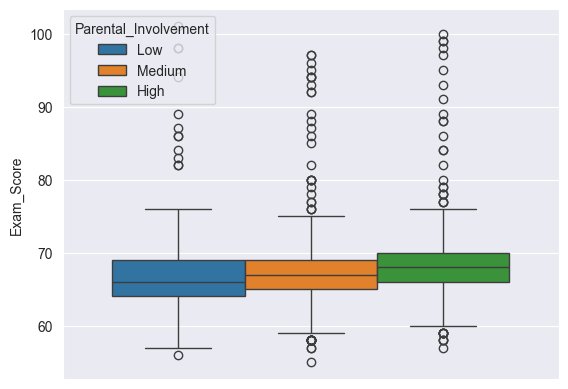

In [14]:
sns.boxplot(data=df, hue=cat_feature, y=target)

# Напишем собственную имплементацию One-Way ANOVA

In [20]:
def one_way_anova(data: pd.DataFrame, target: str, feature: str):
    df = data[[target, feature]].dropna()

    groups = df.groupby(feature)[target]
    group_values = [group.values for _, group in groups]

    k = len(group_values)
    n = len(df)

    grand_mean = df[target].mean()

    ssb = 0.0
    for group in group_values:
        n_i = len(group)
        mean_i = np.mean(group)
        ssb += n_i * (mean_i - grand_mean) ** 2

    ssw = 0.0
    for group in group_values:
        mean_i = np.mean(group)
        ssw += np.sum((group - mean_i) ** 2)

    df_between = k - 1
    df_within = n - k

    msb = ssb / df_between
    msw = ssw / df_within

    f_stat = msb / msw
    p_value = 1 - f.cdf(f_stat, df_between, df_within)

    table = pd.DataFrame({
        "SS": [ssb, ssw],
        "df": [df_between, df_within],
        "ms": [msb, msw],
    }, index=["Between groups", "Within groups"])

    return {
        "F": f_stat,
        "p_value": p_value,
        "ANOVA table": table,
    }

In [22]:
results = one_way_anova(df, target, cat_feature)

print(f"F-статистика: {results['F']}")
print(f"P-value: {results['p_value']}")
print(f"ANOVA table:")
print(results['ANOVA table'])

F-статистика: 84.48765484606163
P-value: 0.0
ANOVA table:
                          SS    df           ms
Between groups   2494.498775     2  1247.249388
Within groups   97491.579929  6604    14.762505


Мы получили p-value очень близкое к нулю, а значит признак статистически значимый

# Проверим результаты с помощью StatsModels

In [16]:
model = smf.ols(f'{target}~{cat_feature}', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=1)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
Parental_Involvement,2.0,2494.498775,1247.249388,84.487655,5.875479e-37
Residual,6604.0,97491.579929,14.762505,NaN,NaN


Результаты сошлись, метод реализован верно